# Lagrange multipliers and the Boltzmann distribution

The previous notebooks *counted* microstates ($W=N!/\prod n_i!$) and *used* the exponential law
$f_{\rm MB}=A\,e^{-E/k_BT}$. This notebook *derives* that law from first principles. The physical claim
is: the equilibrium distribution is the one that maximizes the number of microstates $W$ (equivalently
the entropy $S=k_B\ln W$) subject to two conservation constraints,

$$\sum_i n_i = N \quad(\text{fixed particle number}),\qquad \sum_i n_i E_i = U \quad(\text{fixed energy}).$$

Maximizing a function subject to constraints is exactly the job of **Lagrange multipliers**. Carrying
it out yields $n_i = e^{-\alpha-\beta E_i}$, and thermodynamics identifies the second multiplier as
$\beta = 1/k_BT$. The same constrained-maximization is the maximum-entropy principle of statistics and
the **softmax** function of machine learning -- one piece of mathematics, three vocabularies.

Self-contained: NumPy, SymPy, Pandas, Matplotlib only.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The method of Lagrange multipliers

To maximize $f(\mathbf x)$ subject to $g(\mathbf x)=c$, introduce a multiplier $\lambda$ and solve
$\nabla f = \lambda\,\nabla g$ together with the constraint. Geometrically, at the optimum the level
surface of $f$ is tangent to the constraint surface. A minimal example: maximize the product $xy$ for
fixed sum $x+y=s$. SymPy returns the symmetric solution $x=y=s/2$.

In [2]:
x, y, s, lam = sp.symbols('x y s lambda', positive=True)
f = x*y                      # objective
g = x + y - s                # constraint g = 0
sol = sp.solve([sp.diff(f - lam*g, x), sp.diff(f - lam*g, y), g], [x, y, lam], dict=True)[0]
print("maximize x*y with x+y=s  ->  x =", sol[x], ", y =", sol[y], ", lambda =", sol[lam])
assert sol[x] == s/2 and sol[y] == s/2

maximize x*y with x+y=s  ->  x = s/2 , y = s/2 , lambda = s/2


## Stirling's approximation

The count $\ln W=\ln N!-\sum_i\ln n_i!$ is intractable until we approximate the factorials. For large
$n$, $\ln n!\approx n\ln n-n$ (Stirling). Its derivative is the clean $\dfrac{d}{dn}\ln n!\approx\ln n$,
which is all the derivation needs.

In [3]:
import math
def stirling(n): return n*np.log(n) - n
for n in (10, 100, 1000):
    exact = math.lgamma(n+1)                      # ln(n!) exactly
    print(f"n={n:5d}:  ln(n!) exact = {exact:12.3f},  Stirling = {stirling(n):12.3f},"
          f"  rel.err = {abs(stirling(n)-exact)/exact:.2e}")
# the derivative used below: d/dn [n ln n - n] = ln n
assert abs((stirling(1000.0001)-stirling(1000))/0.0001 - np.log(1000)) < 1e-3

n=   10:  ln(n!) exact =       15.104,  Stirling =       13.026,  rel.err = 1.38e-01
n=  100:  ln(n!) exact =      363.739,  Stirling =      360.517,  rel.err = 8.86e-03
n= 1000:  ln(n!) exact =     5912.128,  Stirling =     5907.755,  rel.err = 7.40e-04


## Deriving $n_i = e^{-\alpha-\beta E_i}$

Maximize $\ln W$ subject to the two constraints by extremizing the Lagrangian
$$\mathcal L=\ln W-\alpha\Big(\sum_i n_i-N\Big)-\beta\Big(\sum_i n_i E_i-U\Big),$$
with $\ln W\approx N\ln N-\sum_i(n_i\ln n_i-n_i)$ (Stirling). Setting $\partial\mathcal L/\partial n_i=0$
uses $\partial(\text -n_i\ln n_i+n_i)/\partial n_i=-\ln n_i$, giving $-\ln n_i-\alpha-\beta E_i=0$, hence
$$\boxed{\,n_i=e^{-\alpha-\beta E_i}=A\,e^{-\beta E_i}\,}, \qquad A\equiv e^{-\alpha}.$$
SymPy performs the per-level extremization symbolically.

In [4]:
n, E, alpha, beta = sp.symbols('n_i E_i alpha beta', positive=True)
lnW_term = -(n*sp.log(n) - n)                     # this level's contribution to ln W (Stirling)
L_i = lnW_term - alpha*n - beta*E*n               # constraints enter linearly in n_i
n_star = sp.solve(sp.diff(L_i, n), n)[0]          # dL/dn_i = 0
print("dL/dn_i = 0  ->  n_i =", n_star)
assert sp.simplify(n_star - sp.exp(-alpha - beta*E)) == 0
print("=> n_i = e^{-alpha - beta E_i} = A e^{-beta E_i}, with A = e^{-alpha}")

dL/dn_i = 0  ->  n_i = exp(-E_i*beta - alpha)
=> n_i = e^{-alpha - beta E_i} = A e^{-beta E_i}, with A = e^{-alpha}


## Identifying $\beta = 1/k_BT$

The multiplier $\alpha$ (through $A=e^{-\alpha}$) enforces normalization $\sum_i n_i=N$. The multiplier
$\beta$ enforces the energy constraint; comparing $dS=k_B\,d(\ln W)$ with the thermodynamic
$dS=dU/T$ identifies $\beta=1/k_BT$. Substituting recovers exactly the law the earlier notebooks
assumed:
$$n_i=A\,e^{-E_i/k_BT},\qquad A=\frac{N}{\sum_i e^{-E_i/k_BT}}=\frac{N}{Z},$$
where $Z=\sum_i e^{-E_i/k_BT}$ is the **partition function**.

In [5]:
# partition function and probabilities for a small energy ladder
kT = 1.0                                          # work in units of k_B T (so beta = 1)
E = np.array([0.0, 1.0, 2.0, 3.0, 4.0])           # energy levels (units of kT)
Z = np.sum(np.exp(-E/kT))                          # partition function
p = np.exp(-E/kT) / Z                              # Boltzmann probabilities, normalized
print("partition function Z =", round(Z, 4))
print("probabilities p_i    =", np.round(p, 4), " sum =", round(p.sum(), 6))
assert np.isclose(p.sum(), 1.0)
# ratio of adjacent levels is a constant factor e^{-1/kT} (the exponential signature)
assert np.allclose(p[1:]/p[:-1], np.exp(-1.0/kT))

partition function Z = 1.5713
probabilities p_i    = [0.6364 0.2341 0.0861 0.0317 0.0117]  sum = 1.0


## Numerical check: maximum entropy reproduces the exponential

The derivation says the Boltzmann distribution is the *maximum-entropy* distribution at fixed mean
energy. We test this directly: given a target mean $\langle E\rangle$, solve
$\sum_i(E_i-\langle E\rangle)e^{-\beta E_i}=0$ for $\beta$ (a one-dimensional root find, no external
solver needed), form $p_i\propto e^{-\beta E_i}$, and confirm no other distribution with the same mean
has higher entropy $S=-\sum_i p_i\ln p_i$.

In [6]:
def boltzmann_for_mean(E, mean_E, lo=-5.0, hi=5.0):
    # bisection on beta so that <E> = sum E_i p_i matches the target
    def mean_at(b):
        w = np.exp(-b*E); w /= w.sum(); return (E*w).sum()
    for _ in range(200):
        mid = 0.5*(lo+hi)
        if mean_at(mid) > mean_E: lo = mid          # larger beta lowers the mean
        else: hi = mid
    b = 0.5*(lo+hi); w = np.exp(-b*E); return b, w/w.sum()

E = np.arange(6.0)                                  # levels 0..5
target = 1.5
beta, p = boltzmann_for_mean(E, target)
S = -np.sum(p*np.log(p))
print(f"solved beta = {beta:.4f},  <E> = {(E*p).sum():.4f} (target {target}),  S = {S:.4f}")

# perturb toward a neighbour while keeping the mean fixed; entropy must not increase
rng = np.random.default_rng(0)
worse = 0
for _ in range(2000):
    q = p + 1e-2*rng.standard_normal(len(p))
    q = np.clip(q, 1e-9, None); q /= q.sum()
    if abs((E*q).sum() - target) < 1e-3:            # same mean
        if -np.sum(q*np.log(q)) > S + 1e-9: worse += 1
print("perturbations with the same mean that beat Boltzmann's entropy:", worse, "(expected 0)")
assert worse == 0

solved beta = 0.3710,  <E> = 1.5000 (target 1.5),  S = 1.6136
perturbations with the same mean that beat Boltzmann's entropy: 0 (expected 0)


## The computer-engineering payoff: softmax is the Boltzmann distribution

Machine learning turns a vector of scores $\mathbf z$ into probabilities with the **softmax**
$\text{softmax}(\mathbf z)_i=e^{z_i}/\sum_j e^{z_j}$. Setting $z_i=-\beta E_i$ makes this *identically*
the Boltzmann distribution: the network's logits play the role of negative energies and the "inverse
temperature" $\beta$ is the softmax gain. Training with cross-entropy loss is maximum-likelihood
under this model, and the maximum-entropy principle derived above is why softmax is the natural,
least-biased choice. Constrained optimization is thus the same mathematics in a Hamiltonian, a
thermodynamic ensemble, and a neural network.

In [7]:
def softmax(z):
    z = z - z.max()                                 # subtract max for numerical stability
    e = np.exp(z); return e/e.sum()

E = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
beta = 0.8
boltz = np.exp(-beta*E); boltz /= boltz.sum()
assert np.allclose(softmax(-beta*E), boltz)         # softmax(-beta E) == Boltzmann
print("softmax(-beta E) equals the Boltzmann distribution:", np.round(boltz, 4))

# temperature/gain sweep: high beta (low T) -> peaked (argmax); low beta (high T) -> uniform
rows = []
for b in (0.0, 0.5, 1.0, 3.0):
    q = softmax(-b*E)
    rows.append({"beta": b, "T (1/beta)": (np.inf if b==0 else round(1/b,3)),
                 "p(ground)": round(q[0],4), "entropy": round(-np.sum(q*np.log(q)),4)})
print(pd.DataFrame(rows).to_string(index=False))

softmax(-beta E) equals the Boltzmann distribution: [0.5609 0.252  0.1133 0.0509 0.0229]
 beta  T (1/beta)  p(ground)  entropy
  0.0         inf     0.2000   1.6094
  0.5       2.000     0.4287   1.3943
  1.0       1.000     0.6364   1.0000
  3.0       0.333     0.9502   0.2083


## Plots

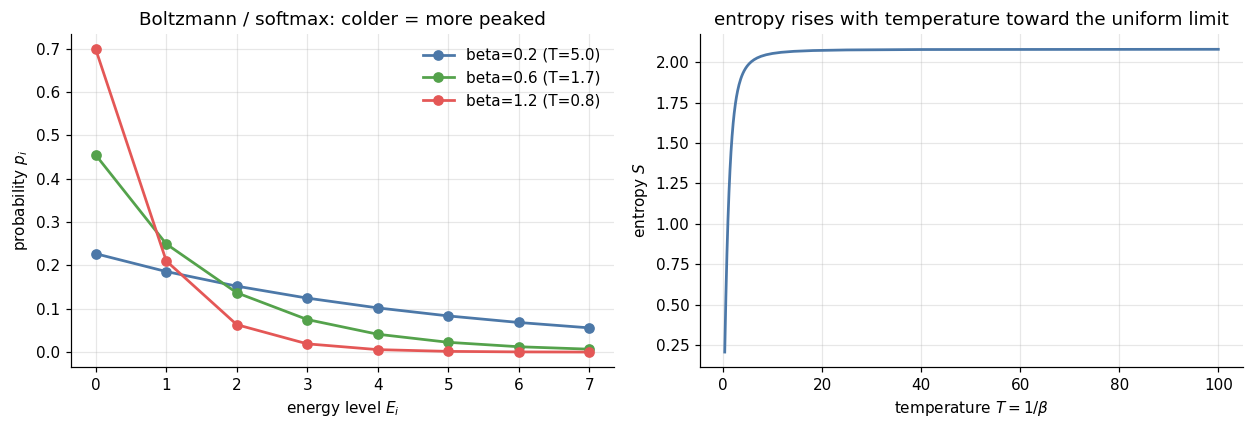

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
E = np.arange(8.0)
for b, c in [(0.2, "#4C78A8"), (0.6, "#54A24B"), (1.2, "#E45756")]:
    q = softmax(-b*E)
    ax[0].plot(E, q, "o-", color=c, label=f"beta={b} (T={1/b:.1f})")
ax[0].set_xlabel("energy level $E_i$"); ax[0].set_ylabel("probability $p_i$")
ax[0].set_title("Boltzmann / softmax: colder = more peaked"); ax[0].legend()

betas = np.linspace(0.01, 3, 200)
Ss = [-(lambda q: np.sum(q*np.log(q)))(softmax(-b*E)) for b in betas]
ax[1].plot(1/betas, Ss, color="#4C78A8")
ax[1].set_xlabel(r"temperature $T = 1/\beta$"); ax[1].set_ylabel("entropy $S$")
ax[1].set_title("entropy rises with temperature toward the uniform limit")
plt.tight_layout(); plt.show()

## A note on exponentials (half-life, decay, and the Boltzmann factor)

The exponential $e^{-\beta E}$ derived here is the same functional form that governs **radioactive
decay** $N(t)=N_0e^{-\lambda t}$ with half-life $t_{1/2}=\ln 2/\lambda$, optical absorption
$I(z)=I_0e^{-\alpha z}$, and $RC$ discharge $V(t)=V_0e^{-t/\tau}$. Each is the solution of a first-order
proportionality (a rate constant, an absorption coefficient, a Lagrange multiplier), which is why the
exponential appears wherever one quantity changes in proportion to itself or is weighted linearly in a
constraint.

In [9]:
ln2 = np.log(2)
for half_life, label in [(5730.0, "carbon-14 (yr)"), (1.28e9, "potassium-40 (yr)")]:
    lam = ln2/half_life
    assert np.isclose(np.exp(-lam*half_life), 0.5)  # one half-life halves the population
    print(f"{label:22s} lambda = {lam:.3e} /yr,  N/N0 after one half-life = "
          f"{np.exp(-lam*half_life):.3f}")

carbon-14 (yr)         lambda = 1.210e-04 /yr,  N/N0 after one half-life = 0.500
potassium-40 (yr)      lambda = 5.415e-10 /yr,  N/N0 after one half-life = 0.500


## Summary

- Equilibrium maximizes the microstate count $W$ (entropy $S=k_B\ln W$) under fixed $N$ and $U$;
  **Lagrange multipliers** turn this constrained maximization into $\partial\mathcal L/\partial n_i=0$.
- The result is $n_i=e^{-\alpha-\beta E_i}=A\,e^{-E_i/k_BT}$: the exponential law the earlier notebooks
  assumed is now derived, with $\alpha$ setting normalization and $\beta=1/k_BT$ setting temperature.
- Numerically, the Boltzmann distribution is verified to be the maximum-entropy distribution at fixed
  mean energy, and it is **identically the softmax** with $z_i=-\beta E_i$ -- the bridge to machine
  learning and cross-entropy training.

**Roadmap pointer.** Radiation, mentioned in passing, has the same two-viewpoint structure as this
chapter: Griffiths' electrodynamics gives the deterministic Larmor power $P=\mu_0 q^2 a^2/6\pi c$ of a
*single accelerating charge*, while statistical mechanics gives the Planck blackbody spectrum of a
*thermal ensemble* -- microscopic law versus ensemble average, the recurring theme from microstates
onward.